In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg')  
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  

import seaborn as sns

# For our regression model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

sns.set(style="whitegrid")
print('Libraries imported successfully.')


Libraries imported successfully.


In [2]:
data_path = 'delhi_pm25_aqi (1).csv'
df = pd.read_csv(data_path, encoding='utf-8')

print('Data loaded successfully. Here are the first few rows:')
df.head()


Data loaded successfully. Here are the first few rows:


,value,parameter.name,parameter.units,period.datetimeFrom.utc
0,300.0,pm25,µg/m³,2016-11-02T17:30:00Z
1,93.0,pm25,µg/m³,2016-11-03T10:45:00Z
2,93.0,pm25,µg/m³,2016-11-03T11:00:00Z
3,93.0,pm25,µg/m³,2016-11-03T11:15:00Z
4,93.0,pm25,µg/m³,2016-11-03T11:30:00Z


In [ ]:

df.rename(columns={
    'value': 'pm25',
    'parameter.name': 'parameter',
    'parameter.units': 'units',
    'period.datetimeFrom.utc': 'datetime_utc'
}, inplace=True)


df['datetime_utc'] = pd.to_datetime(df['datetime_utc'], errors='coerce')


missing_values = df.isnull().sum()
print('Missing values in each column:')
print(missing_values)


df = df.dropna(subset=['datetime_utc'])


df['year'] = df['datetime_utc'].dt.year
df['month'] = df['datetime_utc'].dt.month
df['day'] = df['datetime_utc'].dt.day
df['hour'] = df['datetime_utc'].dt.hour


df['timestamp'] = df['datetime_utc'].apply(lambda x: x.timestamp())

print('Data cleaning and preprocessing complete. Here are the updated columns:')
print(df.columns.tolist())

Missing values in each column:
pm25            0
parameter       0
units           0
datetime_utc    0
dtype: int64
Data cleaning and preprocessing complete. Here are the updated columns:
['pm25', 'parameter', 'units', 'datetime_utc', 'year', 'month', 'day', 'hour', 'timestamp']


Descriptive statistics for PM2.5 values
count    10000.000000
mean       153.270270
std        127.310869
min          6.000000
25%         64.000000
50%        114.000000
75%        201.000000
max        997.500000
Name: pm25, dtype: float64


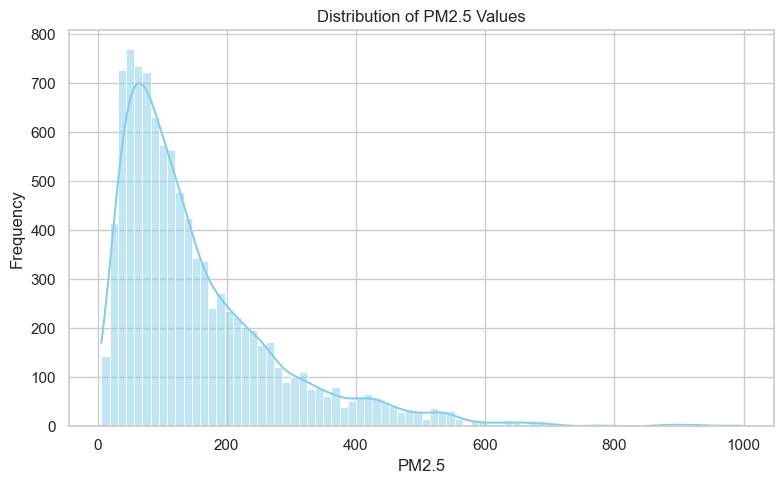

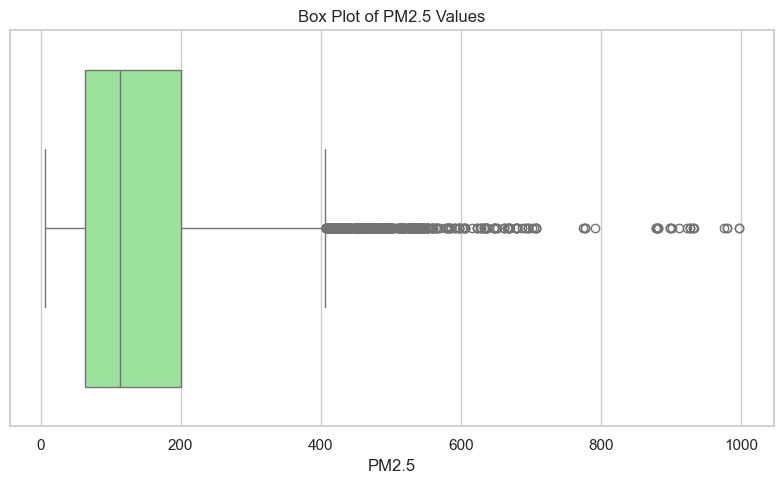

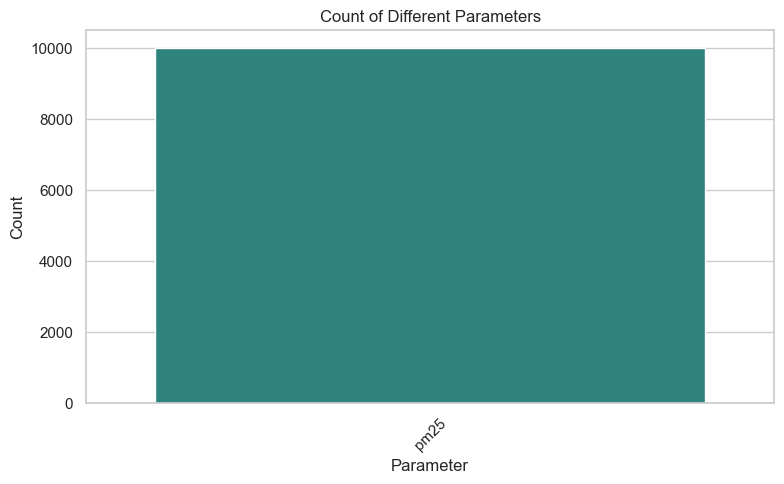

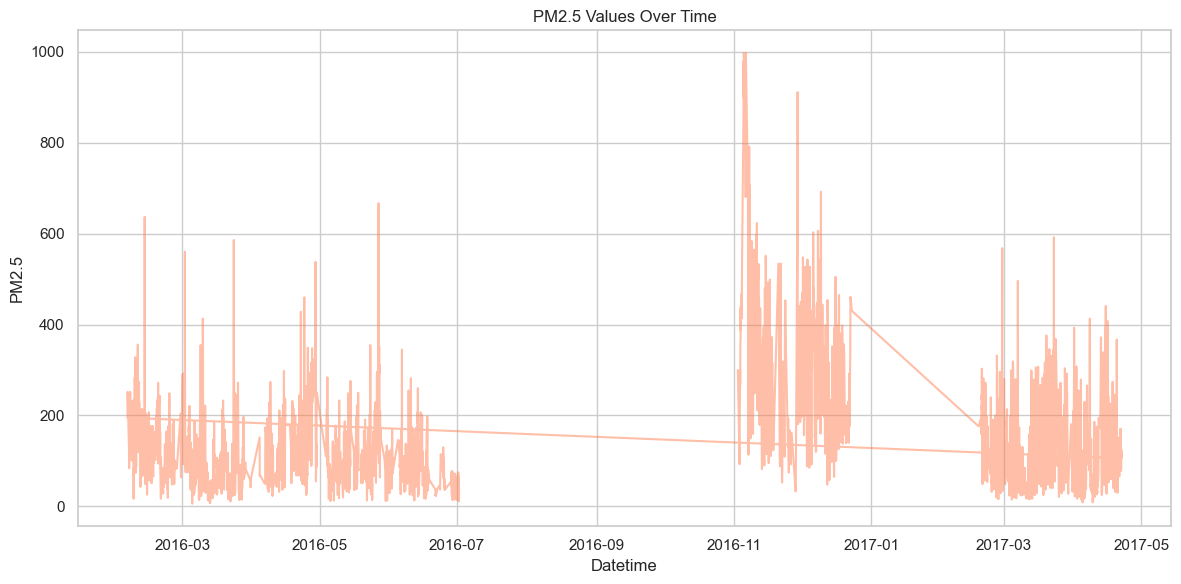

In [ ]:

print('Descriptive statistics for PM2.5 values')
print(df['pm25'].describe())


plt.figure(figsize=(8, 5))
sns.histplot(df['pm25'], kde=True, color='skyblue')
plt.title('Distribution of PM2.5 Values')
plt.xlabel('PM2.5')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
sns.boxplot(x=df['pm25'], color='lightgreen')
plt.title('Box Plot of PM2.5 Values')
plt.xlabel('PM2.5')
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='parameter', palette='viridis')
plt.title('Count of Different Parameters')
plt.xlabel('Parameter')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))
plt.plot(df['datetime_utc'], df['pm25'], alpha=0.5, color='coral')
plt.title('PM2.5 Values Over Time')
plt.xlabel('Datetime')
plt.ylabel('PM2.5')
plt.tight_layout()
plt.show()

Linear Regression Model Performance:
Train R2 Score: 0.031
Test R2 Score: 0.026


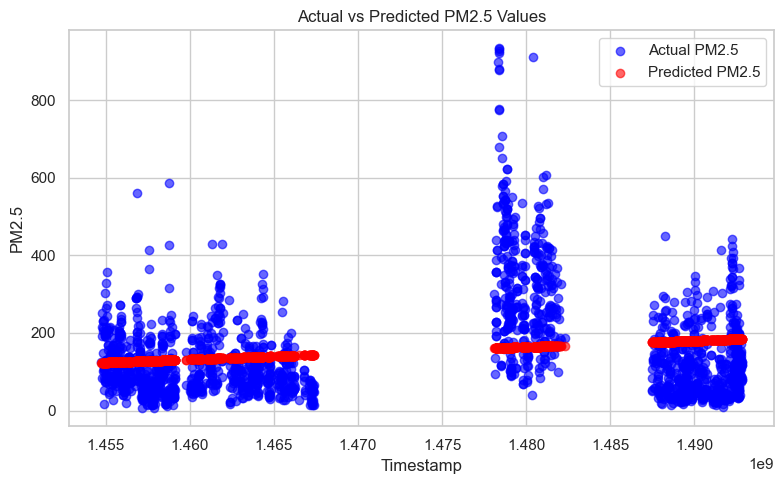

In [ ]:



features = df[['timestamp']]
target = df['pm25']


X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_score = r2_score(y_train, y_train_pred)
test_score = r2_score(y_test, y_test_pred)

print('Linear Regression Model Performance:')
print(f'Train R2 Score: {train_score:.3f}')
print(f'Test R2 Score: {test_score:.3f}')


plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='blue', label='Actual PM2.5', alpha=0.6)
plt.scatter(X_test, y_test_pred, color='red', label='Predicted PM2.5', alpha=0.6)
plt.title('Actual vs Predicted PM2.5 Values')
plt.xlabel('Timestamp')
plt.ylabel('PM2.5')
plt.legend()
plt.tight_layout()
plt.show()



In [6]:
import joblib

joblib.dump(model, "aqi_model.pkl")


['aqi_model.pkl']